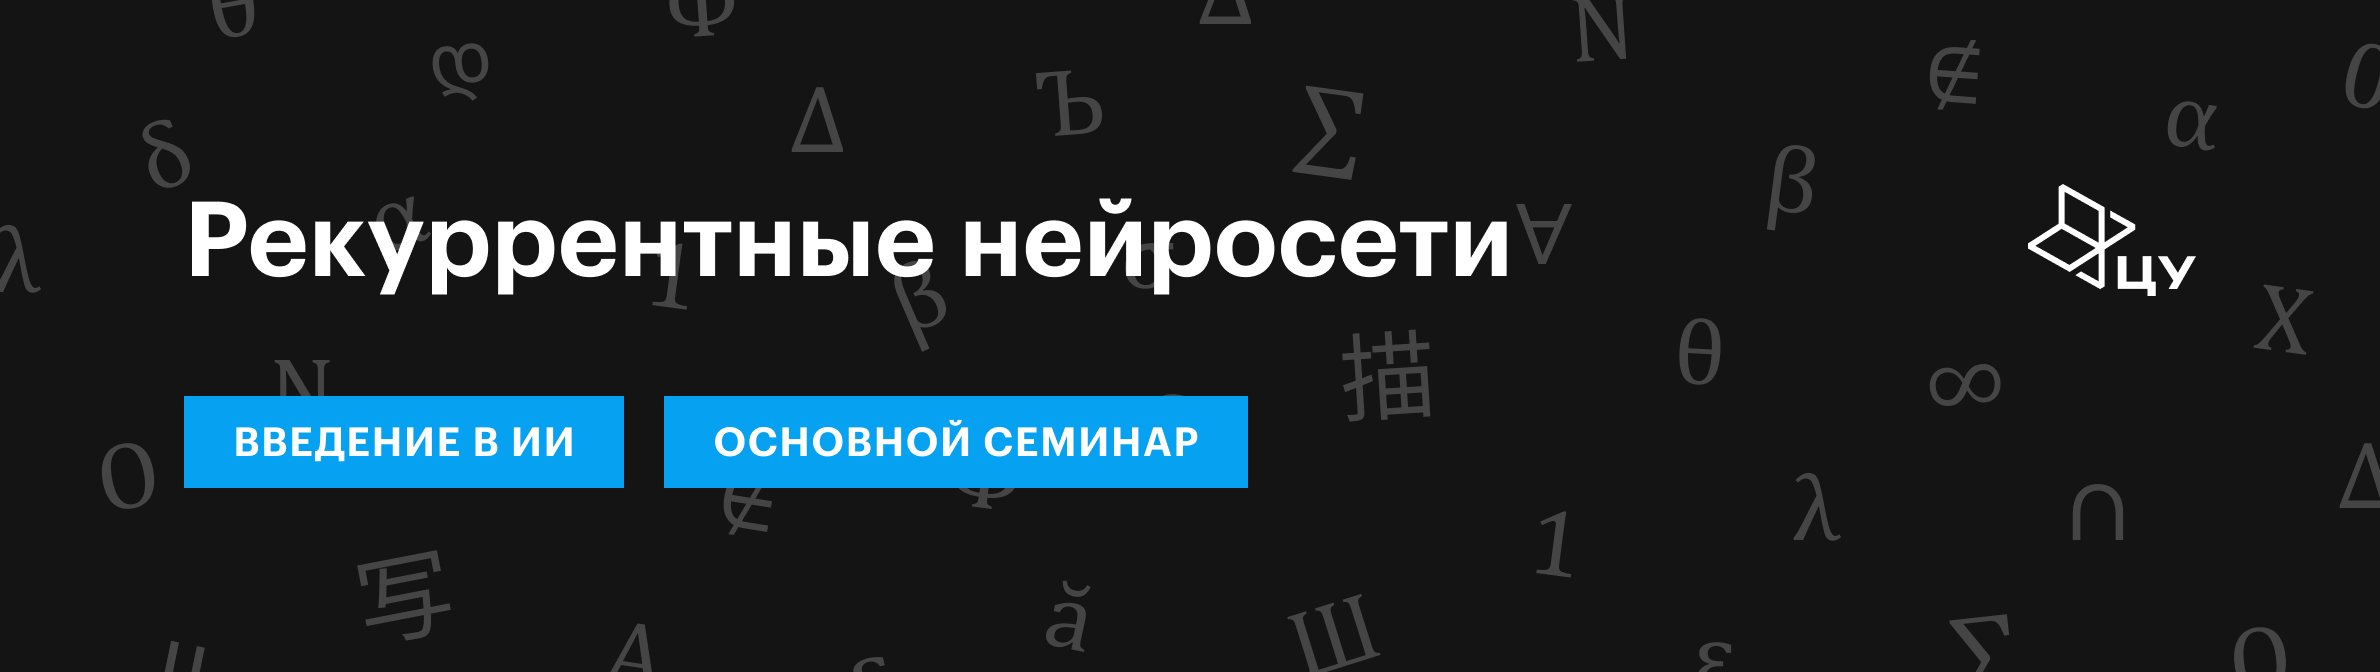

# Семинар по теме «Рекуррентные нейронные сети»
Сегодня на практике ты познакомишься с реккурентными нейронными сетями (Recurrent Neural Network, RNN):
*   применишь RNN для прогнозирования последовательности данных,
*   самостоятельно создашь RNN,
*   познакомишься с нейросетевыми эмбеддингами,
*   решишь задачу генерации имён с помощью RNN и эмбеддингов.

## Как работает RNN

> **Рекуррентные нейронные сети (англ. Recurrent Neural Network, RNN)** — это класс нейронных сетей для работы с&nbsp;последовательными данными.

Их применяют при обработке:

*   текста,
*   звука,
*   временных рядов.

Такие данные упорядочены: каждый следующий элемент зависит от предыдущих.

Главная особенность RNN — скрытое состояние. Оно хранит информацию о предыдущих элементах последовательности.

Когда модель проходит по последовательности, она обновляет скрытое состояние. Так RNN постепенно накапливает информацию о контексте.

На каждом шаге скрытое состояние вместе с текущими входными данными снова подаётся на вход сети.




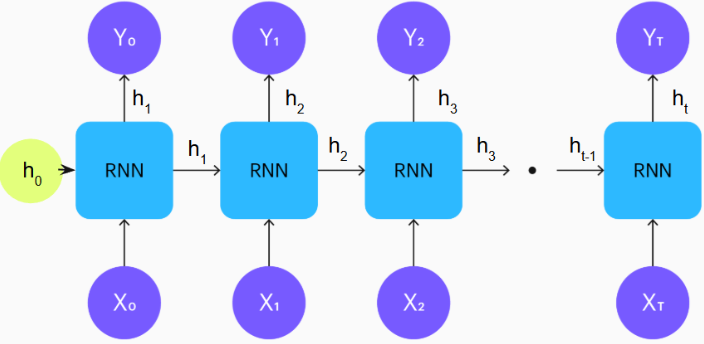

На семинаре мы подробно разберём самую простую «классическую» реализацию RNN. Рассмотрим её схему ниже.

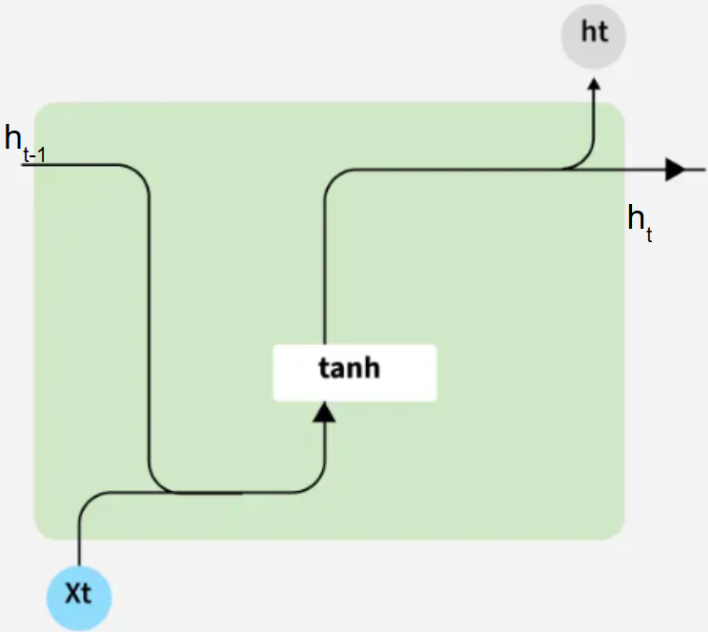

$x_t$ — входные данные. В нашем случае это эмбеддинг текущего токена.


$h_{t-1}$ — скрытое состояние с предыдущего шага RNN. Оно хранит информацию о ранее просмотренных элементах последовательности.

$tanh$ — гиперболический тангенс. Он играет роль функции активации.

$h_t$ — новое скрытое состояние, которое учитывает информацию о последнем просмотренном токене $x_t$.

То есть RNN комбинирует информацию из текущего токена $x_t$ и из просмотренной последовательности $h_{t-1}$, чтобы получить новое скрытое состояние $h_t$. Модель передаёт $h_t$ на выход — например, чтобы определить PoS tag для текущего токена. Затем использует его на следующем шаге RNN.



## Реализация RNN в PyTorch
Перейдём к практике! Сначала разберём, как устроена RNN, а затем с нуля реализуем классическую RNN на PyTorch.


In [ ]:
# Импортируем необходимые пакеты
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

В PyTorch для вычисления $h_t$ используют модуль [RNNCell](https://pytorch.org/docs/stable/generated/torch.nn.RNNCell.html).


`RNNCell` выполняет один шаг RNN. Он обновляет скрытое состояние для одного элемента последовательности.

Пока рассмотрим работу этого слоя без цикла по последовательности.

Основные аргументы:

**`input_size`** — размерность элемента последовательности;

**`hidden_size`** — размерность скрытого состояния.





In [ ]:
# Сгенерируем случайный набор данных размерности batch_size x input_size
batch_size, input_size = 32, 3 # То есть как будто бы у нас табличка из 32 наблюдений и 3 переменных
X = torch.randn((batch_size, input_size))

# Определим один шаг RNN
hidden_size = 6 # Размерность скрытого представления
rnn_cell = nn.RNNCell(input_size, hidden_size)

# Применим rnn_cell как стандатрный блок PyTorch
h = rnn_cell(X)
h.shape

torch.Size([32, 6])

**Вопрос**: почему размерность на выходе блока — 6, если на входе — 3?


###Ответ для семинариста
 Мы задали размерность скрытого состояния как 6 и на выходе из RNN имеем именно скрытое состояние для текущего элемента последовательности.

### Задание 1. Реализация RNNCell

Теперь реализуй `RNNCell` самостоятельно.
1. Создай два линейных слоя:

    *   первый — чтобы преобразовать входной вектор в вектор размерности скрытого состояния,
    *   второй — чтобы преобразовать текущее скрытое состояние.

2. Создай начальное скрытое состояние. Это нулевой необучаемый вектор.
3. Реализуй основную формулу RNN в `forward`.


### Ответ для семинариста

In [ ]:
class CustomRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
      super().__init__()
      self.W_hx = nn.Linear(input_size, hidden_size) # Линейный слой для преобразования размерности входа к размерности скрытого состояния
      self.W_hh = nn.Linear(hidden_size, hidden_size) # Линейный слой для преобразования текущего скрытого состояния
      self.h0 = nn.Parameter(torch.zeros((hidden_size)), requires_grad=False)  # Изначально скрытое состояние инициализируется нулями. Оберни в nn.Parameter и выключи градиенты.

    def forward(self, x, h=None):
      # Если скрытое состояние не подано на вход, то используем начальное
      if h is None:
          h = self.h0
      return torch.tanh(self.W_hx(x) + self.W_hh(h))

Теперь проверим, как работает получившийся `RNNCell`.


In [ ]:
# Инициализируем
custom_rnn_cell = CustomRNNCell(input_size, hidden_size)

# Применяем
h = custom_rnn_cell(X)
h.shape

torch.Size([32, 10, 6])

Рассмотренный выше `RNNCell` — это лишь часть полноценной RNN. Он обрабатывает один элемент последовательности и возвращает новое скрытое состояние.

Поэтому входные данные должны иметь размерность:

размер батча × длина последовательности × размерность входа.

Но нам нужно работать со всей последовательностью. Для этого `RNNCell` применяют последовательно к каждому элементу и сохраняют промежуточные скрытые состояния.

В PyTorch это уже реализовано в виде слоя [RNN](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html).

Его основные аргументы:

*   `input_size` — размерность элемента последовательности,
*   `hidden_size` — размерность скрытого состояния,
*   `batch_first` — положение размерности батча во входном тензоре.

По умолчанию `batch_first` = `False`. Однако всегда устанавливают `batch_first` = `True`, потому что размерность батча обычно помещают в начало.


**Слой RNN возвращает два тензора**

*   `output` — тензор размерности:
размер батча × длина последовательности × размерность скрытого состояния.
Он содержит скрытые состояния для всех элементов последовательности.
*   `hn` — тензор размерности:
1 × размер батча × размерность скрытого состояния. Это последнее скрытое состояние. Оно совпадает с последним элементом последовательности из `output`.


In [ ]:
# Сгенерируем случайный набор данных размерности batch_size x seq_len x input_size
batch_size, seq_len, input_size = 32, 10, 3 # То есть как будто бы у нас табличка из 32 наблюдений в 10 разных моментов времени и 3 переменных
X = torch.randn((batch_size, seq_len, input_size))

# Определим RNN
hidden_size = 6 # Размерность скрытого представления
rnn = nn.RNN(input_size, hidden_size, batch_first=True)

# Применим RNN как стандатрный блок PyTorch
output, hn = rnn(X)
# Посмотрим на размерности и то, действительно ли совпадают последний элемент из output и hn.
output.shape, hn.shape, (hn[0] == output[:, -1, :]).all()

(torch.Size([32, 10, 6]), torch.Size([1, 32, 6]), tensor(True))

### Задание 2. Реализация RNN

Теперь на основе `CustomRNNCell` реализуй полноценную RNN.

Аргумент `batch_first` можно не учитывать. Считай, что батч всегда стоит в первом измерении.

В этом задании нужно реализовать метод `forward` для RNN. Для каждого элемента последовательности:

*   вычисли новое скрытое состояние по текущему входу и предыдущему скрытому состоянию,
*   сохрани его в контейнере.

### Ответ для семинариста

In [ ]:
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
      super().__init__()
      self.rnn_cell = CustomRNNCell(input_size, hidden_size) # Инициализируем самописную RNNCell

    def forward(self, x, h=None):
      all_h = [] # Контейнер для промежуточных скрытых состояний
      for i in range(x.shape[1]):  # Итерируемся по размерности времени
          h = self.rnn_cell(torch.Tensor(x[:, i, :]), h) # На каждой итерации RNNCell подаём новый элемент последовательности и прошлое скрытое состояние
          all_h.append(h) # Добавляем новое скрытое состояние в контейнер
      return torch.stack(all_h, dim=1), h # Возвращаем все скрытые состояния (dim = 1, чтобы размерность времени была 2-й) и последнее скрытое состояние

In [ ]:
# Проверим работоспособность
custom_rnn = CustomRNN(input_size, hidden_size)

# Применим RNN как стандартный блок PyTorch
output, hn = custom_rnn(X)
# Посмотрим на размерности и то, действительно ли совпадают последний элемент из output и hn.
output.shape, hn.shape, (hn == output[:, -1, :]).all()

(torch.Size([32, 10, 6]), torch.Size([32, 6]), tensor(True))

## Пример обучения RNN на временном ряду
Теперь проверим, всё ли работает. Обучим модель на синтетической последовательности чисел.

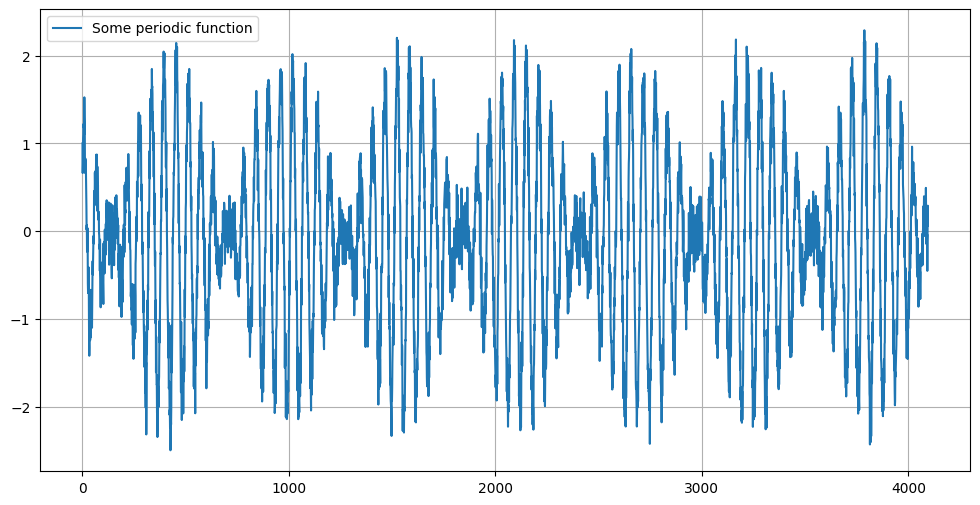

In [ ]:
# Создадим датасет и визуализируем его
training_data = []
for i in range(4096):
    training_data.append(
        np.sin(i / 10) + np.cos(i / 9) + (np.random.randn() - 0.5) / 5 # Sin и Cos + шумовая компонента
    )

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(training_data, label="Some periodic function")
plt.legend()
plt.grid()
plt.show()

Теперь соберём датасет. По окну прошлых наблюдений будем предсказывать одно будущее наблюдение. То есть нужно последовательность чисел нарезать на окна.

In [ ]:
# Функция, чтобы нарезать наши данные на окна.  Вход: прошлые наблюдения — Выход: предсказанное будущее наблюдение
def sliding_windows(data, seq_len):
  '''
  data — входные данные
  seq_len — длина каждого кусочка данных (по какому количеству прошлых наблюдений предсказываем будущее)
  '''
  x = [] # Контейнер для последовательностей
  y = [] # Контейнер для целевой переменной

  for i in range(len(data) - seq_len):
      _x = data[i : (i + seq_len)]
      _y = data[i + seq_len]
      x.append(_x)
      y.append(_y)

  return torch.Tensor(np.array(x)), torch.Tensor(np.array(y))

Разделим датасет на обучение и тест.

In [ ]:
# Создаём датасет в удобном формате
seq_len = 8
x, y = sliding_windows(training_data, seq_len)

# И делим его по переменной времени
train_size = int(len(y) * 0.8)

x_train = x[:train_size]
y_train = y[:train_size]

x_test = x[train_size:]
y_test = y[train_size:]

In [ ]:
x_train.shape

torch.Size([3270, 8])

**Вопрос**: чего не хватает в наших данных для обучения RNN?

### Ответ для семинариста
Размерности скрытого состояния. RNN требует на вход данные размерности [bs, seq_len, hid_dim]. То есть надо добавить ещё размерность, пусть она и единичная.

### Задание 3. Подготовка датасета для RNN
Определим класс `RNNDataset`, который понадобится для обучения.

Что нужно добавить в его реализацию?


### Ответ для семинариста

In [ ]:
class RNNDataset(Dataset):
  def __init__(self, data, targets):

    self.data = data.unsqueeze(-1)
    self.targets = targets

  def __len__(self):
      return len(self.targets)

  def __getitem__(self, idx):
      return self.data[idx], self.targets[idx]

Инициализируем `RNNDatаset` и `DataLoader` для наших подвыборок.

In [ ]:
batch_size = 32
train_ds = RNNDataset(x_train, y_train)
test_ds = RNNDataset(x_test, y_test)

train_dl = DataLoader(train_ds, batch_size=batch_size)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

###Задание 4. Модель для проверки самописной RNN

Определим модель, которая будет предсказывать следующее значение последовательности.
Модель должна возвращать одно число, а выход RNN имеет размерность скрытого состояния.

Чтобы получить одно число, применим к выходу RNN линейный слой. Тебе нужно:

*   применить самописную RNN,
*   применить линейный слой к её последнему скрытому состоянию,
*   привести выход модели к размерности вектора, чтобы `loss` корректно вычислялся.


### Ответ для семинариста

In [ ]:
class SeriesRNN(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()

    self.rnn = CustomRNN(input_size, hidden_size) # Самописная RNN
    self.linear = nn.Linear(hidden_size, 1) # Скрытое состояние преобразуем к ответу

  def forward(self, x):
      _, h = self.rnn(x)
      return self.linear(h).squeeze() # Примени линейный слой и убери единичную размерность, потому что целевая переменная — это вектор

Теперь пришло время обучить модель. Единственное небольшое изменение находится в `valid_step`. Раньше мы его использовали для классификации, а теперь — для регрессии.

In [ ]:
# Функция для одного шага обучения
def train_step(batch, model, loss, optimizer, device):

    model.zero_grad()

    X, y = batch
    X = X.to(device)
    y = y.to(device)

    logits = model(X)
    l = loss(logits, y)

    l.backward()
    optimizer.step()

    return l.item()

In [ ]:
# Функция для обучения на эпохе
def train(model, loss, optimizer, device, train_dataloader):
    model.train()
    train_loss = 0

    for batch in train_dataloader:
      loss_step = train_step(batch, model, loss, optimizer, device)

      # Накапливаем функцию потерь, усредняя её между всеми батчами
      train_loss += loss_step / len(train_dataloader)

    return train_loss

In [ ]:
# Функция для одного шага валидации
def valid_step(batch, model, loss, device):

      X, y = batch
      X = X.to(device)
      y = y.to(device)

      with torch.no_grad():
        logits = model(X)
        l = loss(logits, y)

      return logits.cpu().numpy(), l.item() # Единственное небольшое изменение здесь. Возвращаем теперь логиты, а не классы, как в прошлый раз при использовании этой функции

In [ ]:
# Функция для всей валидации на эпохе, будем использовать её также для получения предсказаний
def validate(model, loss, device, val_dataloader):
  model.eval()
  val_loss = 0
  preds = []
  for batch in val_dataloader:
    preds_step, loss_step = valid_step(batch, model, loss, device)

    val_loss += loss_step / len(val_dataloader)
    preds.append(preds_step)

  preds = np.concatenate(preds)

  return preds, val_loss

In [ ]:
# Объединяем обучение и валидацию
def train_and_validate(epochs, model, loss, optimizer, device, train_dataloader, val_dataloader, save_every=1, naming=''):

    model.to(device)

    for e in range(epochs):

        train_loss = train(model, loss, optimizer, device, train_dataloader)
        val_preds, val_loss = validate(model, loss, device, val_dataloader)

        print(f'Эпоха: {e} | Train Loss {train_loss} | Val Loss {val_loss}')

        # Хорошей практикой является сохранение весов модели каждые n шагов или эпох. Тут мы сохраняем по эпохам
        if e % save_every == 0:
            torch.save(model.state_dict(), f'model_epoch_{e}{naming}.pth')

Инициализируем оптимизатор, модель и функцию потерь, а затем проведём обучение.


**Вопрос**: какую функцию потерь будем использовать?

###Ответ для семинариста
Модель предсказывает вещественное значение, то есть мы решаем задачу регрессии.

Для обучения используем функцию потерь MSE.


### Задание 5. Функция потерь
Определи функцию потерь, о которой говорилось выше.

### Ответ для семинариста

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SeriesRNN(1, 3).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1) # Наш оптимизатор
loss = nn.MSELoss() # Определи функцию потерь
epochs = 10

Запускаем функцию обучения.

In [ ]:
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)

Эпоха: 0 | Train Loss 0.16859331897016866 | Val Loss 0.10712834332997986
Эпоха: 1 | Train Loss 0.09073075536385328 | Val Loss 0.10039990997085206
Эпоха: 2 | Train Loss 0.08486224895397437 | Val Loss 0.10088242189242287
Эпоха: 3 | Train Loss 0.08114545202805 | Val Loss 0.10434814284627254
Эпоха: 4 | Train Loss 0.07838721030834807 | Val Loss 0.10572575104351224
Эпоха: 5 | Train Loss 0.07646624660752349 | Val Loss 0.10280366385212313
Эпоха: 6 | Train Loss 0.0750591201544965 | Val Loss 0.09590436976689558
Эпоха: 7 | Train Loss 0.07339850476789248 | Val Loss 0.08197767516741385
Эпоха: 8 | Train Loss 0.07217699994595307 | Val Loss 0.07763982320634216
Эпоха: 9 | Train Loss 0.07120771386018658 | Val Loss 0.07582499545354111


Функция потерь заметно уменьшилась.
Чтобы проверить результат, построим график предсказаний.


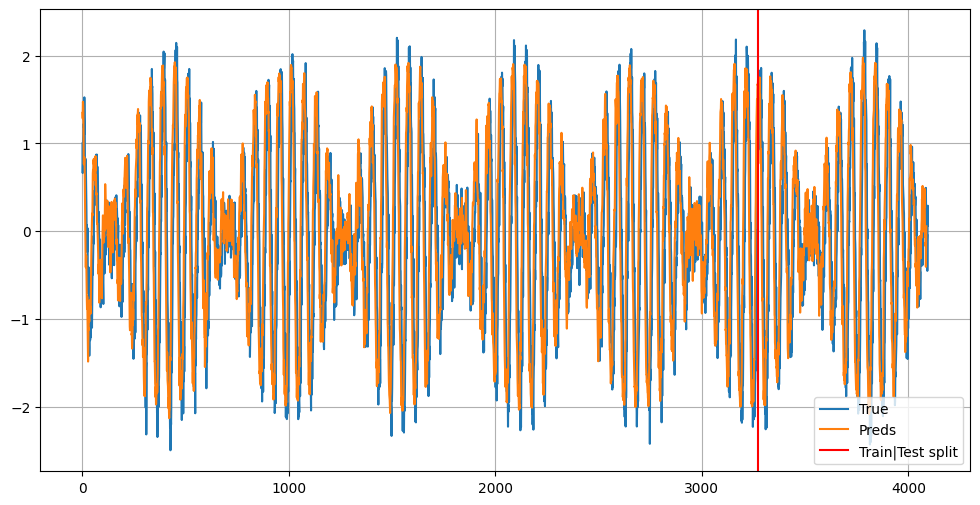

In [ ]:
# Воспользуемся функцией validate, чтобы получить предсказания
train_preds, _ = validate(model, loss, device, train_dl)
test_preds, _ = validate(model, loss, device, test_dl)
preds = np.concatenate([train_preds, test_preds])

# Отрисуем результаты
plt.figure(figsize=(12, 6))
plt.plot(training_data, label='True')
plt.plot(preds, label='Preds')
plt.axvline(x=train_size, color='red', label='Train|Test split')
plt.legend()
plt.grid()
plt.show()

Предсказания хорошо совпадают с данными, значит, модель реализована правильно.


## Генерация имён с помощью RNN

Мы разобрали, как устроена RNN. Теперь применим её для обработки текста.

Чтобы обучить полноценную языковую модель, потребуется больше времени, чем есть на семинаре. Поэтому рассмотрим задачу с прошлой недели — генерацию правдоподобных имён.

Использование RNN усложнит модель, но позволит заметно улучшить качество генерации.


Вспомним, как выглядел датасет.

In [ ]:
# Загружаем датасет. Две ссылки, потому что там мужские и женские имена
!gdown 12HpgM5c2W5jgG8cwbSZTlLSfbo_cpTJL
!gdown 1GAPiDQCKoqNBD0gG01gF-s5glHL3rKuq

# Считываем имена
names = open('russian_female_names.txt', 'r').read().splitlines()
names.extend(open('russian_male_names.txt', 'r').read().splitlines())

# В датасете есть ошибки. В одном имени заменили «c» русскую на «c» английскую. В 3 других «н» заменена на «h». Удалим их
for n in ['cергей', 'hаталья', 'hадежда', 'hиколай']:
  names.remove(n)

# Женские имена; мужские имена; всего имён
names[:10], names[-10:], len(names),

Downloading...
From: https://drive.google.com/uc?id=12HpgM5c2W5jgG8cwbSZTlLSfbo_cpTJL
To: /content/russian_female_names.txt
100% 19.0k/19.0k [00:00<00:00, 63.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GAPiDQCKoqNBD0gG01gF-s5glHL3rKuq
To: /content/russian_male_names.txt
100% 42.1k/42.1k [00:00<00:00, 87.5MB/s]


(['елена',
  'татьяна',
  'наталья',
  'ольга',
  'мария',
  'анна',
  'ирина',
  'светлана',
  'валентина',
  'людмила'],
 ['микаил',
  'нима',
  'арис',
  'лутфирахман',
  'агли',
  'шайхелислам',
  'наири',
  'анантолий',
  'баки',
  'ахметвали'],
 4526)

Это просто список из мужских и женских имён.

Как и на первом семинаре, разобьём каждое имя на буквы и присвоим им индексы.

Добавим ещё один токен — `<P>`, токен паддинга.

Нейросети обучают батчами. У всех элементов внутри батча должна быть одинаковая размерность, но у имён разная длина. Поэтому к более коротким последовательностям добавляют специальные токены паддинга, пока их длина не станет равна максимальной длине в батче.


In [ ]:
# Сначала посчитаем количество уникальных токенов и занумеруем их в правильном порядке
chars = sorted(list(set(''.join(names)))) # Уникальные буквы в отсортированном порядке
itos = {i: s for i,s in enumerate(chars)} # Индексируем токены

# Добавляем служебные токены
itos[len(itos)] = '<S>'
itos[len(itos)] = '<E>'

# Добавляем токен паддинга. Обучение нейросетей идёт батчами, в батчах длина должна быть вюду одинаковая,
# поэтому короткие имена надо искусственно удлинить токеном паддинга
itos[len(itos)] = '<P>'

# Обратная индексация
stoi = {s: i for i, s in itos.items()}
PAD_IDX = stoi['<P>'] # Эта переменная нам ещё пригодится в выборе эмбеддинга и вычислении функции потерь

In [ ]:
itos

{0: '-',
 1: 'а',
 2: 'б',
 3: 'в',
 4: 'г',
 5: 'д',
 6: 'е',
 7: 'ж',
 8: 'з',
 9: 'и',
 10: 'й',
 11: 'к',
 12: 'л',
 13: 'м',
 14: 'н',
 15: 'о',
 16: 'п',
 17: 'р',
 18: 'с',
 19: 'т',
 20: 'у',
 21: 'ф',
 22: 'х',
 23: 'ц',
 24: 'ч',
 25: 'ш',
 26: 'ы',
 27: 'ь',
 28: 'э',
 29: 'ю',
 30: 'я',
 31: 'ё',
 32: '<S>',
 33: '<E>',
 34: '<P>'}

Чтобы корректно собрать датасет, добавим к каждому имени служебные токены начала и конца последовательности: `<S>` и `<E>`.

После этого разобьём каждое имя на отдельные токены: буквы и служебные символы.


In [ ]:
names = [['<S>'] + list(name) + ['<E>'] for name in names]

Нейросеть работает не с буквами, а с числами. Поэтому каждое имя нужно преобразовать в список индексов соответствующих символов.

Сразу преобразуем эти списки в `torch.tensor`, чтобы не делать это при каждом вызове `__getitem__`.


In [ ]:
names_id = [torch.tensor([stoi[l] for l in name]) for name in names]

In [ ]:
names_id[:10]

[tensor([32,  6, 12,  6, 14,  1, 33]),
 tensor([32, 19,  1, 19, 27, 30, 14,  1, 33]),
 tensor([32, 14,  1, 19,  1, 12, 27, 30, 33]),
 tensor([32, 15, 12, 27,  4,  1, 33]),
 tensor([32, 13,  1, 17,  9, 30, 33]),
 tensor([32,  1, 14, 14,  1, 33]),
 tensor([32,  9, 17,  9, 14,  1, 33]),
 tensor([32, 18,  3,  6, 19, 12,  1, 14,  1, 33]),
 tensor([32,  3,  1, 12,  6, 14, 19,  9, 14,  1, 33]),
 tensor([32, 12, 29,  5, 13,  9, 12,  1, 33])]

Наша задача — по известной части последовательности предсказать следующую букву. Поэтому датасет нужно подготовить в соответствующем формате.

На каждом шаге RNN модель предсказывает следующую букву и сравнивает её с целевой — реальной следующей буквой в имени.

Для этого формируем две последовательности:

*   входная последовательность — имя без последней буквы,
*   целевая последовательность — имя без первой буквы.

Например, по первой букве модель предсказывает вторую, по первым двум — третью и так далее.

Таким образом, каждая пара данных имеет вид:

*   вход — исходная последовательность без последней буквы,
*   ответ — исходная последовательность без первой буквы.

Сформируем такой датасет.


In [ ]:
input_seq = [] # Контейнер для входа в модель переменной
target_seq = [] # Контейнер для целевой последовательности

for name in names_id:
    input_seq.append(name[:-1])
    target_seq.append(name[1:])

In [ ]:
input_seq[0], target_seq[0]

(tensor([32,  6, 12,  6, 14,  1]), tensor([ 6, 12,  6, 14,  1, 33]))

Входная и целевая последовательности различаются сдвигом на один символ — это и требуется для обучения модели.

Теперь можем определить класс датасета, который будет использоваться для обучения модели генерации имён.

In [ ]:
class NameDataset(Dataset):
  def __init__(self, input_seq, target_seq):

    self.input_seq = input_seq
    self.target_seq = target_seq

  def __len__(self):
      return len(self.input_seq)

  def __getitem__(self, idx):
      return self.input_seq[idx], self.target_seq[idx]

Если передать такой датасет в `DataLoader`, он не сможет собрать батч: последовательности имеют разную длину.

Чтобы это исправить, зададим `collate_fn` — функцию, которую передают в `DataLoader`. Она определяет, как из отдельных объектов собирается батч.

В нашей `collate_fn` будем дополнять каждую последовательность токеном паддинга до максимальной длины в батче.

Для этого используем встроенные инструменты PyTorch.


In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
  inputs, targets = zip(*batch) # Распаковываем батч на вход и целевую переменную

  # Добавляем паддинг
  padded_input = pad_sequence(
      inputs,
      batch_first=True, # Размерность батча хотим в начале
      padding_value=PAD_IDX # Индекс токена паддинга, мы его определили, когда собирали словарь
      )

  padded_target = pad_sequence(
      targets,
      batch_first=True,
      padding_value=PAD_IDX
    )

  return padded_input, padded_target

In [ ]:
# Определяем датасет и DataLoader
batch_size = 32
name_ds = NameDataset(input_seq, target_seq)
name_dl = DataLoader(name_ds, batch_size=batch_size, collate_fn=collate_fn)

In [ ]:
# Проверяем работоспособность
for X, y in name_dl:
  break

X.shape, y.shape

(torch.Size([32, 11]), torch.Size([32, 11]))

In [ ]:
X[:5], y[:5]

(tensor([[32,  6, 12,  6, 14,  1, 34, 34, 34, 34, 34],
         [32, 19,  1, 19, 27, 30, 14,  1, 34, 34, 34],
         [32, 14,  1, 19,  1, 12, 27, 30, 34, 34, 34],
         [32, 15, 12, 27,  4,  1, 34, 34, 34, 34, 34],
         [32, 13,  1, 17,  9, 30, 34, 34, 34, 34, 34]]),
 tensor([[ 6, 12,  6, 14,  1, 33, 34, 34, 34, 34, 34],
         [19,  1, 19, 27, 30, 14,  1, 33, 34, 34, 34],
         [14,  1, 19,  1, 12, 27, 30, 33, 34, 34, 34],
         [15, 12, 27,  4,  1, 33, 34, 34, 34, 34, 34],
         [13,  1, 17,  9, 30, 33, 34, 34, 34, 34, 34]]))

### Задание 6. RNN для предсказания следующей буквы

Теперь применим RNN для предсказания следующей буквы. В отличие от вещественной последовательности, буква — это категориальный признак.

1. Теперь мы решаем задачу классификации по размеру словаря. Соответственно, размерность линейного слоя на выходе будет отличаться.
2. Вход также изменился. Категории должны быть закодированы в векторы. Поэтому необходимо добавить обучаемый слой [nn.Embedding](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html). К нему можно обращаться по индексу и извлекать векторные представления букв, которые нужны на данный момент.


**В этом задании нужно:**

1. создать обучаемый слой эмбеддингов;

2. создать самописную RNN, которая принимает эмбеддинги на вход;

3. сделать выходной линейный слой для предсказания следующей буквы;

4. заполнить пропуски в методе forward, чтобы модель работала корректно.


### Ответ для семинариста

In [ ]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size=len(itos), emb_dim=8, hidden_dim=16):
      super().__init__()

      self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX) # Укажи индекс для токена паддинга, чтобы он не обучался (всё равно он не нужен в обученном виде)
      self.rnn = CustomRNN(emb_dim, hidden_dim)
      self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h=None): # h нам пригодится на этапе генерации, чтобы не пересчитывать последовательность каждый раз заново
      x = self.emb(x) # Получи векторные представления для индексов
      out, h = self.rnn(x, h) # Прямой проход по RNN
      return self.fc(out), h # Верни предсказания следующей буквы и также последнее скрытое состояние (пригодится для целей генерации)

Теперь можно переходить к обучению. Так как у нас задача классификации, то будем использовать `CrossEntropyLoss`. Ей также можно передать информацию о токене паддинга, чтобы он не участовал в вычислении функции потерь.

In [ ]:
epochs = 1000
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Инициализируем модель, функцию потерь и оптимизатор. Здесь SGD справлялся плохо, поэтому взяли более продвинутый AdamW
model = CharRNN(emb_dim=16, hidden_dim=32)
loss = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

Обучим модель. Для простоты в этот раз обойдёмся без валидации.

Перед обучением нужно дополнительно обработать выход модели. В текущем виде его нельзя напрямую передать в функцию потерь.

Когда модель проходит по последовательности, она решает не `batch_size` задач классификации, а `batch_size` × `seq_len`. Поэтому перед вычислением функции потерь выход модели нужно преобразовать: объединить предсказания по всем позициям в один массив.

Именно это происходит в `train_step`. В остальном обучение не меняется.

In [ ]:
# Функция для одного шага обучения
def train_step(batch, model, loss, optimizer, device):

    model.zero_grad()

    X, y = batch
    X = X.to(device)
    y = y.to(device)

    logits, _ = model(X) # Сейчас bs, seq_len, hid_dim, a надо bs * seq_len, hid_dim
    l = loss(logits.view(-1, logits.size(-1)), y.view(-1))

    l.backward()
    optimizer.step()

    return l.item()

Обучаем. Можно оставновить обучение существенно раньше. Например, после 100 эпох. Дальше качество растет, но не очень быстро. Пока учится, можно реализовать следующее задание.

In [ ]:
model.to(device)
for e in range(epochs+1):
  train_loss = train(model, loss, optimizer, device, name_dl)

  if e % 100 == 0:
    print(f'Эпоха: {e} | Train Loss {train_loss}')

Эпоха: 0 | Train Loss 3.3478346727263752
Эпоха: 100 | Train Loss 2.11642048644348
Эпоха: 200 | Train Loss 2.054710656824247
Эпоха: 300 | Train Loss 2.0264378945592427


KeyboardInterrupt: 

### Задание 7. Функция для генерации имён

Реализуем функцию, которая по заданному префиксу генериует правдоподобное имя.
1. Для текущего префикса получим последнее скрытое состояние и ответ модели.
2. Ответ модели преобразуем к вероятностям с помощью `F.softmax` и сгенерируем индекс следующей буквы из мультиномиального распределения `torch.multinomial`.
3. Декодируем и сохраним ответ модели
4. Скрытое состояние и ответ модели передаём в следующую итерацию генерации.
5. Повторяем шаги 1–4, пока не достигнута максимальная длина имени или не сгенерирован токен конца последовательности.

### Ответ для семинариста

In [ ]:
@torch.no_grad() # Декоратором выключаем градиенты для модели, так как они нам не нужны
def generate_name(model=model, prefix="", max_len=30, device="cpu"):
    model.eval() # Переводим модель в режим инференса
    model.to(device)
    result = list(prefix) # Контейнер для ответа
    # Если передана пустая строка, то начинаем генерацию с символа начала генерации
    if prefix == "":
      seq = [stoi['<S>']]
    else:
      seq = [stoi['<S>']] + [stoi[c] for c in prefix]

    seq = torch.tensor(seq, dtype=torch.long, device=device).unsqueeze(0) # Делаем из индексов тензор и добаляем размерность батча

    # Обрабатываем текущую входную последовательность и сохраняем последнее скрытое состояние. Оно будет использоваться для дальнейшей генерации
    with torch.inference_mode():
      output, h = model(seq)

    probs = F.softmax(output[:, -1, :], dim=-1) # Получаем вероятности из логитов
    next_idx = torch.multinomial(probs, 1).item() # Из мультиномиального распределения с полученными вероятностями достаём индекс следующего символа

    result.append(itos[next_idx])

    # Генерируем, пока не встретим символ конца имени или не превысим максимальную длину
    while max_len - len(prefix) > 0:
      output, h = model(torch.tensor([next_idx]).view((1, 1)), h)
      probs = F.softmax(output[:, -1, :], dim=-1)
      next_idx = torch.multinomial(probs, 1).item()

      if next_idx == stoi['<E>']:
        break

      result.append(itos[next_idx])

    return "".join(result)

In [ ]:
# Случайная генерация
for _ in range(10):
  print(generate_name())

мавлавия
сатруля
рудан
лло
эляс
рашабий
влар
фахита
фитит
янса


In [ ]:
# Начинается с буквы «а»
for _ in range(10):
  print(generate_name(prefix='а'))

арисман
авфа
арин
ардус
антён
арик
аносла
аксан
агиль
алеена


In [ ]:
# Начинается с буквы «в»
for _ in range(10):
  print(generate_name(prefix='в'))

вясаф
визян
вальела
вафинина
владжи
вима
вальсий
вананга
веридон
верюсла


Качество сгенерированных имён заметно выросло по сравнению с результатами прошлого семинара.
